# Evaluating boost mdoels

## Objective
Extend the FOMC rate-decision forecasting framework to output **probability distributions** across three outcomes — `Lower`, `Same`, `Higher` — rather than a single hard prediction. This probabilistic framing enables:
- Identifying **economic regimes** (inflationary vs. contractionary) from the shape of the distribution
- Quantifying model **uncertainty** at each FOMC meeting
- Better calibration for downstream decision-making

**Features used** (all lagged to prevent leakage):
- WTI Crude Oil 30-day average (lags 1–4)
- Unemployment Rate — UNRATE (lags 1–4)
- CPI Year-over-Year % (lags 1–4)
- Previous Fed Funds Target Rate (lags 1–4)
- Derived trend / inertia features

## Test Methodology: Walk-Forward (Expanding Window) Validation
For each FOMC meeting at index $t$, starting from `INITIAL_TRAIN_SIZE = 40`:
1. Train on all meetings $[0, t)$
2. Predict **probability distribution** $[P(\text{Lower}), P(\text{Same}), P(\text{Higher})]$ for meeting $t$
3. Record distribution → advance $t$ by 1

## Models & Soft-Probability Method
| Model | Soft-probability method |
|---|---|
| **XGBoost** | `objective='multi:softprob'` → `predict_proba()` |
| **LightGBM** | `predict_proba()` |
| **CatBoost** | `predict_proba()` |
| **HistGradientBoosting** | `predict_proba()` |

Hyperparameters are **pre-tuned via Optuna** in `boosting_models.ipynb` and hardcoded here.

## Evaluation Metrics
| Metric | Purpose |
|---|---|
| Accuracy / F1 Macro | Hard-label quality (argmax of probs) |
| **Brier Score** | Probability calibration (lower = better) |
| **Log-Loss** | Entropy of predicted distributions (lower = better) |

> **Class imbalance note:** ~77 % of meetings are "Same", 15 % "Higher", 8 % "Lower".
> All models use balanced class weights. **F1 Macro** is the primary hard-label metric.


In [13]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, log_loss, brier_score_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier

# ── Optional packages ─────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed — skipping')

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed — skipping')

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost not installed — skipping')

print('All imports OK')
print(f'  XGBoost : {XGBOOST_AVAILABLE}')
print(f'  LightGBM: {LGBM_AVAILABLE}')
print(f'  CatBoost: {CATBOOST_AVAILABLE}')

All imports OK
  XGBoost : True
  LightGBM: True
  CatBoost: True


---
## 1. Data Loading & Feature Setup

In [14]:
_DATA_URL = 'https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data/df_model.csv'
df_model = pd.read_csv(_DATA_URL, parse_dates=['meeting_date'])

print(f'Loaded df_model: {df_model.shape[0]} rows × {df_model.shape[1]} columns')
print(f'Date range     : {df_model["meeting_date"].min().date()} → {df_model["meeting_date"].max().date()}')
print()
print('Decision distribution:')
print(df_model['decision'].value_counts())

Loaded df_model: 135 rows × 26 columns
Date range     : 2009-09-23 → 2026-01-28

Decision distribution:
decision
same      104
higher     20
lower      11
Name: count, dtype: int64


In [15]:
# ── Feature / Label Setup ─────────────────────────────────────────────────────
NON_FEATURE_COLS = ['meeting_date', 'decision', 'decision_num', 'prev_decision']
feature_cols = [c for c in df_model.columns if c not in NON_FEATURE_COLS]

X = df_model[feature_cols].values.astype(float)      # shape (N, ~22)
y_orig = df_model['decision_num'].values.astype(int)  # -1 = Lower, 0 = Same, 1 = Higher
meeting_dates = df_model['meeting_date'].values

# XGBoost / LightGBM / CatBoost require 0-indexed integer labels
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}   # original → encoded
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}   # encoded  → original
ENCODED_NAMES = { 0: 'Lower', 1: 'Same', 2: 'Higher'}
LABEL_VALS    = [-1, 0, 1]
LABEL_STRS    = ['Lower', 'Same', 'Higher']
# Encoded order: 0=Lower, 1=Same, 2=Higher

y_enc = np.array([LABEL_MAP[v] for v in y_orig])    # 0, 1, 2

print(f'Features: {len(feature_cols)}')
print(f'Samples : {len(X)}')
print(f'Label distribution (encoded): {dict(zip(*np.unique(y_enc, return_counts=True)))}')
print('  0=Lower, 1=Same, 2=Higher')

Features: 22
Samples : 135
Label distribution (encoded): {0: 11, 1: 104, 2: 20}
  0=Lower, 1=Same, 2=Higher


---
## 2. Best Hyperparameters (from Optuna in `boosting_models.ipynb`)

In [16]:
# ── Pre-tuned hyperparameters (Optuna, boosting_models.ipynb) ─────────────────
BEST_PARAMS = {
    'XGBoost': dict(
        n_estimators     = 471,
        max_depth        = 3,
        learning_rate    = 0.161042,
        subsample        = 0.712890,
        colsample_bytree = 0.847161,
        min_child_weight = 3,
        gamma            = 0.360274,
        reg_alpha        = 0.243105,
        reg_lambda       = 3.207902,
    ),
    'LightGBM': dict(
        n_estimators      = 500,
        num_leaves        = 42,
        learning_rate     = 0.056209,
        subsample         = 0.685067,
        colsample_bytree  = 0.849375,
        min_child_samples = 17,
        reg_alpha         = 0.658121,
        reg_lambda        = 3.342565,
    ),
    'CatBoost': dict(
        iterations          = 331,
        depth               = 2,
        learning_rate       = 0.018522,
        l2_leaf_reg         = 3.272855,
        bagging_temperature = 0.324958,
    ),
    'HistGradientBoosting': dict(
        max_iter          = 478,
        max_depth         = 4,
        learning_rate     = 0.036259,
        min_samples_leaf  = 3,
        l2_regularization = 2.391524,
        max_leaf_nodes    = 38,
    ),
}

print('Pre-tuned hyperparameters loaded:')
for name, params in BEST_PARAMS.items():
    print(f'  {name}: {params}')

Pre-tuned hyperparameters loaded:
  XGBoost: {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.161042, 'subsample': 0.71289, 'colsample_bytree': 0.847161, 'min_child_weight': 3, 'gamma': 0.360274, 'reg_alpha': 0.243105, 'reg_lambda': 3.207902}
  LightGBM: {'n_estimators': 500, 'num_leaves': 42, 'learning_rate': 0.056209, 'subsample': 0.685067, 'colsample_bytree': 0.849375, 'min_child_samples': 17, 'reg_alpha': 0.658121, 'reg_lambda': 3.342565}
  CatBoost: {'iterations': 331, 'depth': 2, 'learning_rate': 0.018522, 'l2_leaf_reg': 3.272855, 'bagging_temperature': 0.324958}
  HistGradientBoosting: {'max_iter': 478, 'max_depth': 4, 'learning_rate': 0.036259, 'min_samples_leaf': 3, 'l2_regularization': 2.391524, 'max_leaf_nodes': 38}


---
## 3. Walk-Forward Validation Helpers (Probability Output)

In [17]:
INITIAL_TRAIN_SIZE = 40

def augment_missing_classes(X_train, y_train, all_classes=(0, 1, 2)):
    """
    Inject one synthetic sample per missing class (mean features, tiny weight).
    Ensures all 3 classes are always present — critical for multiclass softmax.
    Returns (X_aug, y_aug, sample_weights).
    """
    present = set(y_train)
    missing = set(all_classes) - present

    class_counts = np.bincount(y_train, minlength=3)
    n_total      = len(y_train)
    real_weights = np.array([n_total / (3 * max(class_counts[c], 1)) for c in y_train],
                             dtype=float)

    if not missing:
        return X_train, y_train, real_weights

    X_mean  = X_train.mean(axis=0, keepdims=True)
    X_synth = np.vstack([X_mean] * len(missing))
    y_synth = np.array(sorted(missing))
    w_synth = np.full(len(missing), 1e-9)

    return (np.vstack([X_train, X_synth]),
            np.concatenate([y_train, y_synth]),
            np.concatenate([real_weights, w_synth]))


def walk_forward_proba(
    fit_fn,
    proba_fn,
    X, y_enc,
    n_start=INITIAL_TRAIN_SIZE,
    verbose=True
):
    """
    Expanding-window walk-forward validation that collects probability distributions.

    Returns
    -------
    actuals_enc : np.array (N_test,)    — true encoded labels {0,1,2}
    probas      : np.array (N_test, 3)  — P(Lower), P(Same), P(Higher) per meeting
    """
    actuals, probas = [], []
    total = len(X) - n_start

    for t in range(n_start, len(X)):
        X_train, y_train = X[:t], y_enc[:t]
        X_test           = X[t:t+1]

        model  = fit_fn(X_train, y_train)
        p_dist = proba_fn(model, X_test)   # shape (1, 3)

        actuals.append(y_enc[t])
        probas.append(p_dist[0])           # shape (3,)

        done = t - n_start + 1
        if verbose and (done % 25 == 0 or done == total):
            p = p_dist[0]
            pred_enc = int(np.argmax(p))
            flag = '✓' if y_enc[t] == pred_enc else '✗'
            print(
                f'  [{done:3d}/{total}]  '
                f'{pd.Timestamp(meeting_dates[t]).date()}  '
                f'true={ENCODED_NAMES[y_enc[t]]:7s}  '
                f'pred={ENCODED_NAMES[pred_enc]:7s}  {flag}  '
                f'[L={p[0]:.2f} S={p[1]:.2f} H={p[2]:.2f}]'
            )

    return np.array(actuals), np.vstack(probas)   # (N,), (N, 3)


def report_prob_metrics(name, actuals_enc, probas):
    """Compute and print metrics for a probabilistic classifier. Returns a results dict."""
    preds_enc    = np.argmax(probas, axis=1)
    actuals_orig = np.array([INV_LABEL_MAP[a] for a in actuals_enc])
    preds_orig   = np.array([INV_LABEL_MAP[p] for p in preds_enc])

    acc    = accuracy_score(actuals_orig, preds_orig)
    f1_mac = f1_score(actuals_orig, preds_orig, labels=LABEL_VALS,
                      average='macro', zero_division=0)
    f1_wt  = f1_score(actuals_orig, preds_orig, labels=LABEL_VALS,
                      average='weighted', zero_division=0)

    y_onehot = label_binarize(actuals_enc, classes=[0, 1, 2])
    logloss  = log_loss(actuals_enc, probas, labels=[0, 1, 2])
    brier    = np.mean([
        brier_score_loss(y_onehot[:, k], probas[:, k])
        for k in range(3)
    ])

    n_test  = len(actuals_orig)
    n_right = int(acc * n_test)

    print('=' * 68)
    print(f'  {name}')
    print('=' * 68)
    print(f'  Accuracy     : {acc:.4f}  ({n_right}/{n_test} correct)')
    print(f'  F1 Macro     : {f1_mac:.4f}  (primary hard-label metric)')
    print(f'  F1 Weighted  : {f1_wt:.4f}')
    print(f'  Log-Loss     : {logloss:.4f}  (↓ better calibration)')
    print(f'  Brier Score  : {brier:.4f}   (↓ better calibration)')
    print()
    print(classification_report(actuals_orig, preds_orig, labels=LABEL_VALS,
                                  target_names=LABEL_STRS, zero_division=0))

    return dict(
        name=name,
        accuracy=acc, f1_macro=f1_mac, f1_weighted=f1_wt,
        log_loss=logloss, brier_score=brier,
        actuals_enc=actuals_enc, preds_enc=preds_enc,
        actuals_orig=actuals_orig, preds_orig=preds_orig,
        probas=probas,
    )


print('Helpers defined.')

Helpers defined.


---
## 4. Walk-Forward Probabilistic Evaluation

Each model returns `[P(Lower), P(Same), P(Higher)]` at every FOMC meeting using the pre-tuned hyperparameters.

In [18]:
# ── 4-cache: Load or Init ─────────────────────────────────────────────────────
# • If a pickle cache exists → loads all model results instantly, no retraining.
# • If no cache → initialises empty final_results; training cells below will run.
# • To force a full re-train: delete the cache file, then re-run from this cell.
# ─────────────────────────────────────────────────────────────────────────────
import os as _os, pickle as _pkl

_CACHE_PATH = _os.path.join(_os.path.abspath('..'), 'data', 'final_results_cache.pkl')

final_results = {}   # always start clean; populated from cache below if available

if _os.path.exists(_CACHE_PATH):
    with open(_CACHE_PATH, 'rb') as _f:
        _cache = _pkl.load(_f)
    final_results = _cache.get('final_results', {})
    # Restore library-availability flags
    if 'XGBOOST_AVAILABLE'  in _cache: XGBOOST_AVAILABLE  = _cache['XGBOOST_AVAILABLE']
    if 'LGBM_AVAILABLE'     in _cache: LGBM_AVAILABLE     = _cache['LGBM_AVAILABLE']
    if 'CATBOOST_AVAILABLE' in _cache: CATBOOST_AVAILABLE = _cache['CATBOOST_AVAILABLE']
    # Restore global prob_* / act_* so every downstream cell works without retraining
    if 'XGBoost'              in final_results:
        prob_xgb  = final_results['XGBoost']['probas']
        act_xgb   = final_results['XGBoost']['actuals_enc']
    if 'LightGBM'             in final_results:
        prob_lgbm = final_results['LightGBM']['probas']
        act_lgbm  = final_results['LightGBM']['actuals_enc']
    if 'CatBoost'             in final_results:
        prob_cat  = final_results['CatBoost']['probas']
        act_cat   = final_results['CatBoost']['actuals_enc']
    if 'HistGradientBoosting' in final_results:
        prob_hgb  = final_results['HistGradientBoosting']['probas']
        act_hgb   = final_results['HistGradientBoosting']['actuals_enc']
    print(f'✅ Cache loaded  →  {_CACHE_PATH}')
    print(f'   Models: {list(final_results.keys())}')
    print('   ↳ Training cells 4a–4d will auto-skip for cached models.')
    print('   ↳ To force re-train: delete cache file, re-run from this cell.')
else:
    print(f'ℹ️  No cache found at {_CACHE_PATH}')
    print('   Run training cells 4a–4d to train models.')
    print('   Cache will be auto-saved after cell 4d finishes.')


✅ Cache loaded  →  /Users/echohuang/Documents/forecasting_fed_rate/data/final_results_cache.pkl
   Models: ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']
   ↳ Training cells 4a–4d will auto-skip for cached models.
   ↳ To force re-train: delete cache file, re-run from this cell.


In [19]:
# ── 4a. XGBoost ───────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    bp = BEST_PARAMS['XGBoost']

    def xgb_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = XGBClassifier(
            **bp,
            objective='multi:softprob',
            num_class=3,
            use_label_encoder=False,
            eval_metric='mlogloss',
            random_state=42, verbosity=0
        )
        m.fit(Xa, ya, sample_weight=sw)
        return m

    def xgb_proba(m, Xt):
        """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
        return m.predict_proba(Xt)

    if 'XGBoost' not in final_results:
        t0 = time.time()
        print('Running XGBoost walk-forward …')
        act_xgb, prob_xgb = walk_forward_proba(xgb_fit, xgb_proba, X, y_enc, verbose=False)
        r = report_prob_metrics('XGBoost', act_xgb, prob_xgb)
        final_results['XGBoost'] = r
        print(f'  ↳ done in {time.time()-t0:.1f}s\n')
    else:
        print('✅ XGBoost already in final_results (cached) — skipping training.')
        prob_xgb = final_results['XGBoost']['probas']
        act_xgb  = final_results['XGBoost']['actuals_enc']
else:
    print('XGBoost not available — skipping.')


✅ XGBoost already in final_results (cached) — skipping training.


In [20]:
# ── 4b. LightGBM ──────────────────────────────────────────────────────────────
if LGBM_AVAILABLE:
    bp = BEST_PARAMS['LightGBM']

    def lgbm_fit(Xtr, ytr):
        # augment_missing_classes ensures all 3 labels are present so
        # predict_proba always returns shape (1, 3) — not (1, 2) when
        # the rare 'Lower' class is absent from early training windows.
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = LGBMClassifier(
            **bp,
            class_weight='balanced',
            random_state=42, verbose=-1, n_jobs=1
        )
        m.fit(Xa, ya, sample_weight=sw)
        return m

    def lgbm_proba(m, Xt):
        """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
        return m.predict_proba(Xt)

    if 'LightGBM' not in final_results:
        t0 = time.time()
        print('Running LightGBM walk-forward …')
        act_lgbm, prob_lgbm = walk_forward_proba(lgbm_fit, lgbm_proba, X, y_enc, verbose=False)
        r = report_prob_metrics('LightGBM', act_lgbm, prob_lgbm)
        final_results['LightGBM'] = r
        print(f'  ↳ done in {time.time()-t0:.1f}s\n')
    else:
        print('✅ LightGBM already in final_results (cached) — skipping training.')
        prob_lgbm = final_results['LightGBM']['probas']
        act_lgbm  = final_results['LightGBM']['actuals_enc']
else:
    print('LightGBM not available — skipping.')


✅ LightGBM already in final_results (cached) — skipping training.


In [21]:
# ── 4c. CatBoost ──────────────────────────────────────────────────────────────
if CATBOOST_AVAILABLE:
    bp = BEST_PARAMS['CatBoost']

    def cat_fit(Xtr, ytr):
        Xa, ya, sw = augment_missing_classes(Xtr, ytr)
        m = CatBoostClassifier(**bp, random_seed=42, verbose=0, thread_count=1)
        m.fit(Xa, ya, sample_weight=sw)
        return m

    def cat_proba(m, Xt):
        """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
        return m.predict_proba(Xt)

    if 'CatBoost' not in final_results:
        t0 = time.time()
        print('Running CatBoost walk-forward …')
        act_cat, prob_cat = walk_forward_proba(cat_fit, cat_proba, X, y_enc, verbose=False)
        r = report_prob_metrics('CatBoost', act_cat, prob_cat)
        final_results['CatBoost'] = r
        print(f'  ↳ done in {time.time()-t0:.1f}s\n')
    else:
        print('✅ CatBoost already in final_results (cached) — skipping training.')
        prob_cat = final_results['CatBoost']['probas']
        act_cat  = final_results['CatBoost']['actuals_enc']
else:
    print('CatBoost not available — skipping.')


✅ CatBoost already in final_results (cached) — skipping training.


In [22]:
# ── 4d. HistGradientBoosting ──────────────────────────────────────────────────
# Why this was slow (three compounding reasons):
#  1. sklearn's Cython backend is slower per split than XGBoost/LightGBM's C++.
#  2. Optuna tuned max_leaf_nodes=38 — ~4.7× more splits/tree vs XGBoost (depth=3→8 leaves).
#  3. No early stopping: all 478 rounds ran every fit, 95 fits = 45,410 boosting rounds.
#
# Fix: early_stopping enabled only when every class has ≥ 2 samples in Xa
# (sklearn's StratifiedShuffleSplit requires that; otherwise ValueError).

bp = BEST_PARAMS['HistGradientBoosting']

def hgb_fit(Xtr, ytr):
    Xa, ya, sw = augment_missing_classes(Xtr, ytr)
    _min_cls = int(np.bincount(ya, minlength=3).min())
    _use_es  = _min_cls >= 2
    m = HistGradientBoostingClassifier(
        **bp,
        class_weight='balanced',
        random_state=42,
        early_stopping=_use_es,
        validation_fraction=0.15,
        n_iter_no_change=20,
    )
    m.fit(Xa, ya, sample_weight=sw)
    return m

def hgb_proba(m, Xt):
    """Returns shape (1, 3): [P(Lower), P(Same), P(Higher)]"""
    return m.predict_proba(Xt)

if 'HistGradientBoosting' not in final_results:
    t0 = time.time()
    print('Running HistGradientBoosting walk-forward …')
    act_hgb, prob_hgb = walk_forward_proba(hgb_fit, hgb_proba, X, y_enc, verbose=True)
    r = report_prob_metrics('HistGradientBoosting', act_hgb, prob_hgb)
    final_results['HistGradientBoosting'] = r
    print(f'  ↳ done in {time.time()-t0:.1f}s\n')
else:
    print('✅ HistGradientBoosting already in final_results (cached) — skipping training.')
    prob_hgb = final_results['HistGradientBoosting']['probas']
    act_hgb  = final_results['HistGradientBoosting']['actuals_enc']


✅ HistGradientBoosting already in final_results (cached) — skipping training.


In [23]:
# ── 4-save: Save Model Cache ───────────────────────────────────────────────────
# Run this once after all 4 training cells complete.
# On the next kernel restart, the "4-cache" cell above will reload everything
# instantly — no retraining needed unless you delete this file.
# ─────────────────────────────────────────────────────────────────────────────
import os as _os, pickle as _pkl

_CACHE_PATH = _os.path.join(_os.path.abspath('..'), 'data', 'final_results_cache.pkl')
_os.makedirs(_os.path.dirname(_CACHE_PATH), exist_ok=True)

_save = {
    'final_results':      final_results,
    'XGBOOST_AVAILABLE':  XGBOOST_AVAILABLE,
    'LGBM_AVAILABLE':     LGBM_AVAILABLE,
    'CATBOOST_AVAILABLE': CATBOOST_AVAILABLE,
}
with open(_CACHE_PATH, 'wb') as _f:
    _pkl.dump(_save, _f)

_size_mb = _os.path.getsize(_CACHE_PATH) / 1e6
print(f'💾 Cache saved  →  {_CACHE_PATH}  ({_size_mb:.1f} MB)')
print(f'   Models: {list(final_results.keys())}')
print()
print('Next session workflow:')
print('  1. Run cells 1–3 (data loading + feature engineering)  ← still needed')
print('  2. Run "4-cache" cell  →  models load in <1 second')
print('  3. Skip cells 4a–4d   →  jump straight to Part 5+')


💾 Cache saved  →  /Users/echohuang/Documents/forecasting_fed_rate/data/final_results_cache.pkl  (0.0 MB)
   Models: ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']

Next session workflow:
  1. Run cells 1–3 (data loading + feature engineering)  ← still needed
  2. Run "4-cache" cell  →  models load in <1 second
  3. Skip cells 4a–4d   →  jump straight to Part 5+


In [24]:

# ── Walk-Forward Sync Check ───────────────────────────────────────────────────
# Step 1: Re-load df_model from source so X always reflects the full dataset.
#         (Stale kernel state can leave X shorter than the CSV, causing all
#          walk-forward predictions to stop early.)
# Step 2: Re-run any model whose probas length != len(X) - INITIAL_TRAIN_SIZE.
# Step 3: Re-sync global prob_*/act_* variables from final_results so that
#         downstream visualization cells always see up-to-date arrays.
print('── Step 1: Reload df_model from source ──────────────────────────────────')
df_model = pd.read_csv(_DATA_URL, parse_dates=['meeting_date'])
_nf_cols      = ['meeting_date', 'decision', 'decision_num', 'prev_decision']
feature_cols  = [c for c in df_model.columns if c not in _nf_cols]
X             = df_model[feature_cols].values.astype(float)
y_orig        = df_model['decision_num'].values.astype(int)
meeting_dates = df_model['meeting_date'].values
LABEL_MAP     = {-1: 0,  0: 1,  1: 2}
INV_LABEL_MAP = { 0: -1, 1: 0,  2: 1}
y_enc         = np.array([LABEL_MAP[v] for v in y_orig])
print(f'  df_model : {len(df_model)} rows  '
      f'({df_model["meeting_date"].min().date()} → {df_model["meeting_date"].max().date()})')
print(f'  X shape  : {X.shape}   ({len(feature_cols)} features)')
_expected_n = len(X) - INITIAL_TRAIN_SIZE
print(f'  Expected walk-forward probas per model: {_expected_n}')
print()
print('── Step 2: Detect & re-run out-of-sync models ───────────────────────────')
_model_registry = []
if XGBOOST_AVAILABLE:
    _model_registry.append(('XGBoost',              xgb_fit,  xgb_proba))
if LGBM_AVAILABLE:
    _model_registry.append(('LightGBM',             lgbm_fit, lgbm_proba))
if CATBOOST_AVAILABLE:
    _model_registry.append(('CatBoost',             cat_fit,  cat_proba))
_model_registry.append(    ('HistGradientBoosting', hgb_fit,  hgb_proba))

_any_rerun = False
for _name, _fit_fn, _proba_fn in _model_registry:
    _actual_n = len(final_results[_name]['probas']) if _name in final_results else -1
    if _actual_n == _expected_n:
        print(f'  ✓  {_name:<26s}  probas={_actual_n}  (in sync)')
    else:
        _reason = ('not yet run' if _actual_n == -1
                   else f'probas={_actual_n}  ≠  expected={_expected_n}')
        print(f'  ⚠  {_name:<26s}  {_reason}  →  re-running …')
        _t0 = time.time()
        _acts, _probs = walk_forward_proba(_fit_fn, _proba_fn, X, y_enc, verbose=False)
        final_results[_name] = report_prob_metrics(_name, _acts, _probs)
        print(f'       ✓  done in {time.time()-_t0:.1f}s   '
              f'(probas now {_probs.shape[0]} rows, '
              f'{meeting_dates[INITIAL_TRAIN_SIZE]} → {meeting_dates[-1]})')
        _any_rerun = True

print()
# ── Step 3: Re-sync global prob_*/act_* variables from final_results ─────────
# The loop above only updates final_results[name]. Without this step, downstream
# visualization cells that reference prob_xgb / prob_lgbm / etc. directly would
# still hold stale (shorter) arrays from the previous kernel run.
print('── Step 3: Re-sync global prob_* / act_* variables ─────────────────────')
if XGBOOST_AVAILABLE and 'XGBoost' in final_results:
    prob_xgb = final_results['XGBoost']['probas']
    act_xgb  = final_results['XGBoost']['actuals_enc']
if LGBM_AVAILABLE and 'LightGBM' in final_results:
    prob_lgbm = final_results['LightGBM']['probas']
    act_lgbm  = final_results['LightGBM']['actuals_enc']
if CATBOOST_AVAILABLE and 'CatBoost' in final_results:
    prob_cat = final_results['CatBoost']['probas']
    act_cat  = final_results['CatBoost']['actuals_enc']
if 'HistGradientBoosting' in final_results:
    prob_hgb = final_results['HistGradientBoosting']['probas']
    act_hgb  = final_results['HistGradientBoosting']['actuals_enc']

for _name in [n for n, *_ in _model_registry]:
    if _name in final_results:
        _n = len(final_results[_name]['probas'])
        print(f'  ✓  {_name:<26s}  prob_* / act_* synced  ({_n} rows)')

print()
if _any_rerun:
    print('✓  Re-sync complete — all models now cover the full window.')
else:
    print('✓  All models already in sync. No re-runs needed.')


── Step 1: Reload df_model from source ──────────────────────────────────
  df_model : 135 rows  (2009-09-23 → 2026-01-28)
  X shape  : (135, 22)   (22 features)
  Expected walk-forward probas per model: 95

── Step 2: Detect & re-run out-of-sync models ───────────────────────────
  ✓  XGBoost                     probas=95  (in sync)
  ✓  LightGBM                    probas=95  (in sync)
  ✓  CatBoost                    probas=95  (in sync)
  ✓  HistGradientBoosting        probas=95  (in sync)

── Step 3: Re-sync global prob_* / act_* variables ─────────────────────
  ✓  XGBoost                     prob_* / act_* synced  (95 rows)
  ✓  LightGBM                    prob_* / act_* synced  (95 rows)
  ✓  CatBoost                    prob_* / act_* synced  (95 rows)
  ✓  HistGradientBoosting        prob_* / act_* synced  (95 rows)

✓  All models already in sync. No re-runs needed.


---
## 5. Model Comparison Summary

In [25]:
rows = []
for r in final_results.values():
    rows.append({
        'Model'       : r['name'],
        'Accuracy'    : round(r['accuracy'],    4),
        'F1 Macro'    : round(r['f1_macro'],    4),
        'F1 Weighted' : round(r['f1_weighted'], 4),
        'Log-Loss'    : round(r['log_loss'],    4),
        'Brier Score' : round(r['brier_score'], 4),
    })

df_compare = pd.DataFrame(rows).sort_values('F1 Macro', ascending=False)
print(df_compare.to_string(index=False))

               Model  Accuracy  F1 Macro  F1 Weighted  Log-Loss  Brier Score
             XGBoost    0.6632    0.6381       0.6738    1.0868       0.1762
            CatBoost    0.6421    0.6174       0.6571    0.8777       0.1739
HistGradientBoosting    0.5684    0.5550       0.5783    1.8361       0.2386
            LightGBM    0.5053    0.5030       0.5093    2.0142       0.2679


---
## 6. Probability Distribution Visualizations

In [26]:
# ── Eval-window setup (shared with downstream cells) ─────────────────────────
# Computes eval_dates and n_eval used by every visualisation cell below.
# All models are guaranteed in-sync by the sync_check cell above.

_n_eval    = len(next(iter(final_results.values()))['probas'])
eval_dates = pd.to_datetime(meeting_dates[INITIAL_TRAIN_SIZE : INITIAL_TRAIN_SIZE + _n_eval])

print(f'Eval window : {_n_eval} meetings  '
      f'({eval_dates[0].date()} → {eval_dates[-1].date()})')
for mk, rv in final_results.items():
    print(f'  {mk:<25s}  probas={rv["probas"].shape}  '
          f'accuracy={rv["accuracy"]:.1%}  log_loss={rv["log_loss"]:.3f}')

# Export for downstream cells
n_eval = _n_eval   # consumed by cells in Sections 6, 7, 8


Eval window : 95 meetings  (2014-09-17 → 2026-01-28)
  XGBoost                    probas=(95, 3)  accuracy=66.3%  log_loss=1.087
  LightGBM                   probas=(95, 3)  accuracy=50.5%  log_loss=2.014
  CatBoost                   probas=(95, 3)  accuracy=64.2%  log_loss=0.878
  HistGradientBoosting       probas=(95, 3)  accuracy=56.8%  log_loss=1.836


In [27]:
# ── Human-readable probability table: last 15 meetings ───────────────────────
N_SHOW = 15

for model_key, r in final_results.items():
    probs = r['probas']
    acts  = r['actuals_enc']
    preds = r['preds_enc']

    print(f'\n{r["name"]} — Last {N_SHOW} meetings')
    print(f'{"Date":<14} {"Actual":<8} {"Pred":<8}'
          f' {"P(Lower)":>9} {"P(Same)":>9} {"P(Higher)":>10}  OK?')
    print('-' * 72)

    for i in range(max(0, len(probs) - N_SHOW), len(probs)):
        flag = '✓' if acts[i] == preds[i] else '✗'
        print(
            f'{str(eval_dates[i].date()):<14}'
            f' {ENCODED_NAMES[acts[i]]:<8}'
            f' {ENCODED_NAMES[preds[i]]:<8}'
            f' {probs[i,0]:>8.1%}'
            f' {probs[i,1]:>9.1%}'
            f' {probs[i,2]:>9.1%}'
            f'   {flag}'
        )


XGBoost — Last 15 meetings
Date           Actual   Pred      P(Lower)   P(Same)  P(Higher)  OK?
------------------------------------------------------------------------
2024-05-01     Same     Same         2.5%     71.6%     25.9%   ✓
2024-06-12     Same     Same         2.0%     61.8%     36.2%   ✓
2024-07-31     Same     Same         1.7%     85.1%     13.2%   ✓
2024-09-18     Lower    Same         1.5%     80.6%     17.9%   ✗
2024-11-07     Lower    Same        11.4%     55.4%     33.2%   ✗
2024-12-18     Lower    Lower       65.0%     16.4%     18.6%   ✓
2025-01-28     Same     Lower       88.9%      7.4%      3.7%   ✗
2025-03-19     Same     Higher       9.7%     30.4%     59.9%   ✗
2025-05-07     Same     Same        34.7%     43.4%     21.9%   ✓
2025-06-18     Same     Same        37.3%     46.1%     16.7%   ✓
2025-07-30     Same     Same        14.1%     70.5%     15.3%   ✓
2025-09-17     Lower    Same        23.4%     60.7%     15.8%   ✗
2025-10-29     Lower    Lower       52

## 6b. Boost Model Predictions vs Macro Indicators — Covariance View

For each test-set FOMC meeting, plot **P(Higher)** and **P(Lower)** for all four boosting models alongside the lagged values of **WTI crude oil**, **CPI YoY%**, and **Unemployment Rate (UNRATE)** that were the model's actual inputs.

Green/red shading marks meetings where the Fed actually raised/cut rates — letting you visually inspect whether the models' probability spikes co-vary with the underlying macro signals.

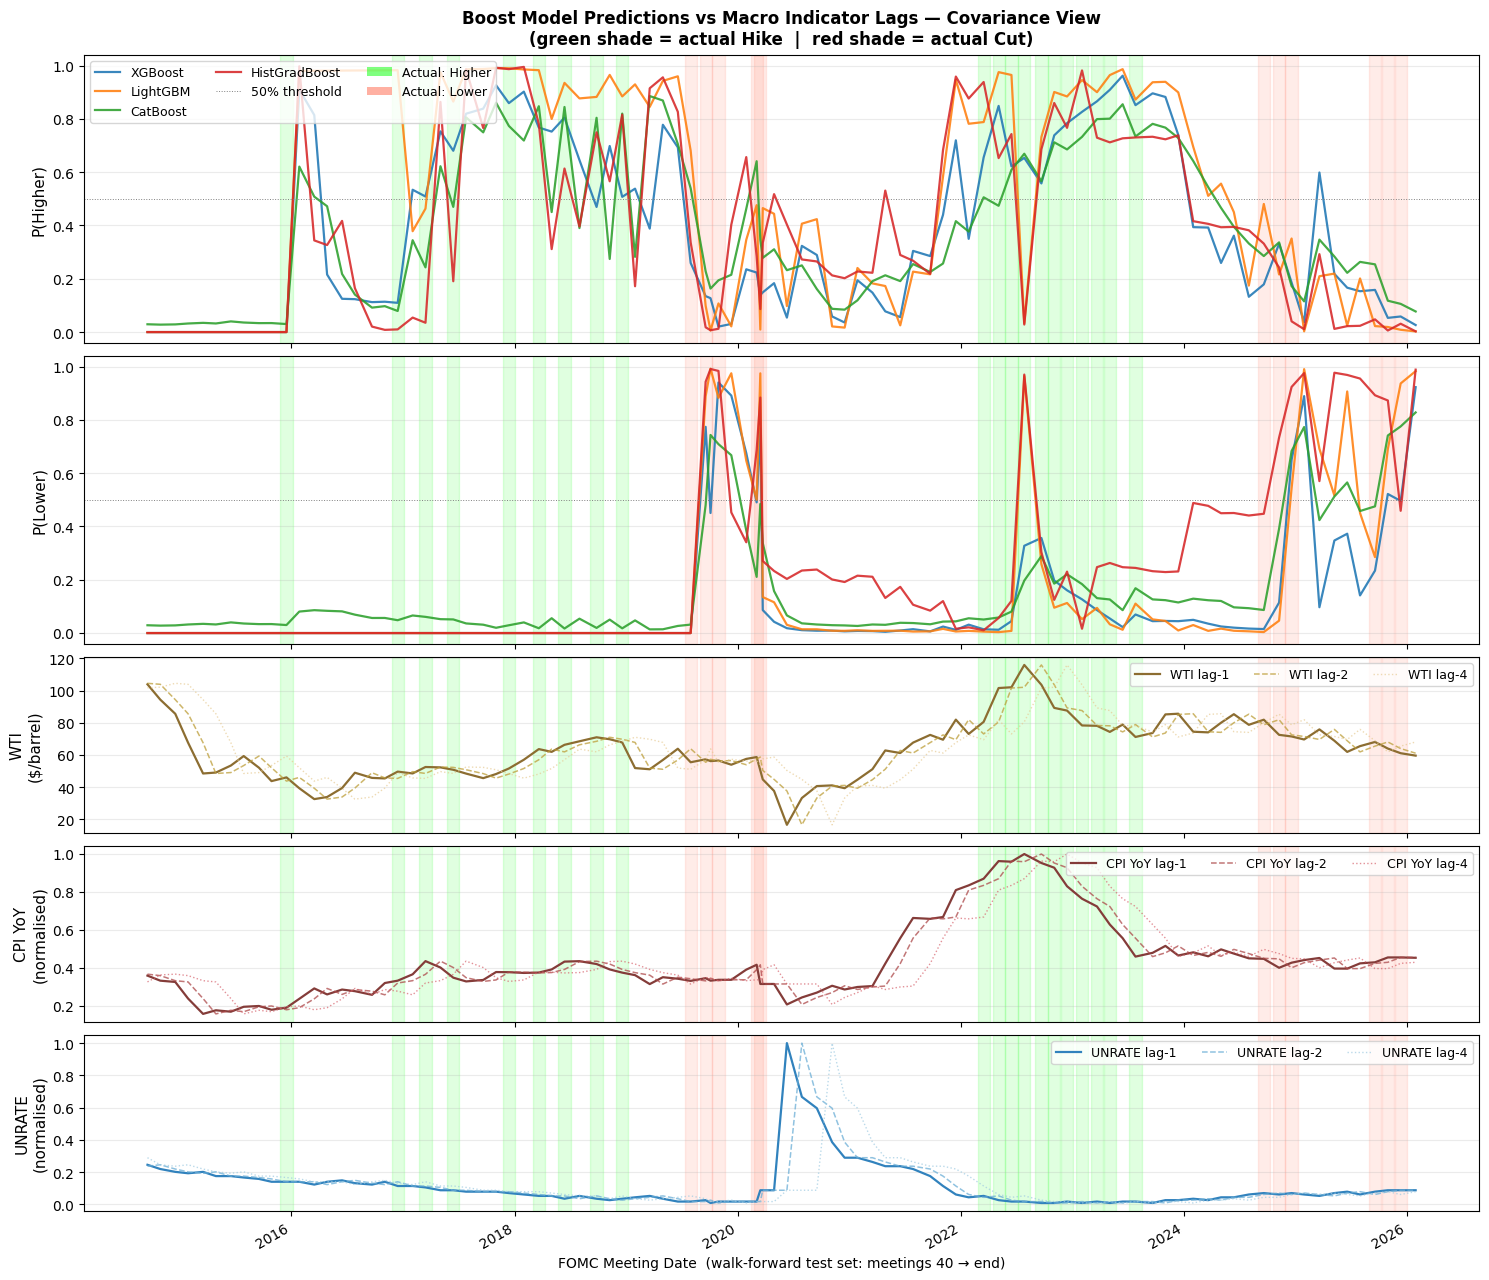

In [28]:

# ── 6b. Boost Models vs Macro Indicators — Covariance View ───────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Build test-set slice ──────────────────────────────────────────────────────
n_start    = INITIAL_TRAIN_SIZE                      # 40
test_dates = pd.to_datetime(meeting_dates[n_start:]) # 95 FOMC meeting dates
df_test    = df_model.iloc[n_start:].copy().reset_index(drop=True)

# Actual decisions in original scale (-1 Lower / 0 Same / 1 Higher)
actual_orig = np.array([INV_LABEL_MAP[a] for a in act_xgb])

# Model names, probability matrices (col 0=Lower, 1=Same, 2=Higher), colours
_models = {
    'XGBoost':       prob_xgb,
    'LightGBM':      prob_lgbm,
    'CatBoost':      prob_cat,
    'HistGradBoost': prob_hgb,
}
_clrs = {
    'XGBoost':       '#1f77b4',
    'LightGBM':      '#ff7f0e',
    'CatBoost':      '#2ca02c',
    'HistGradBoost': '#d62728',
}

higher_mask = actual_orig ==  1   # Fed raised
lower_mask  = actual_orig == -1   # Fed cut

# ── Helper: shade Higher/Lower decision dates across a panel ─────────────────
def _shade(ax):
    for d in test_dates[higher_mask]:
        ax.axvspan(d - pd.Timedelta(days=20), d + pd.Timedelta(days=20),
                   alpha=0.12, color='lime', zorder=0)
    for d in test_dates[lower_mask]:
        ax.axvspan(d - pd.Timedelta(days=20), d + pd.Timedelta(days=20),
                   alpha=0.12, color='tomato', zorder=0)

# ── Figure: 5 panels, shared x-axis ─────────────────────────────────────────
fig, axes = plt.subplots(
    5, 1,
    figsize=(18, 17),
    gridspec_kw={'height_ratios': [1.8, 1.8, 1.1, 1.1, 1.1], 'hspace': 0.06},
    sharex=True,
)

# ─── Panel 0 — P(Higher) for all four models ─────────────────────────────────
ax = axes[0]
_shade(ax)
for name, proba in _models.items():
    ax.plot(test_dates, proba[:, 2], label=name, color=_clrs[name], lw=1.6, alpha=0.88)
ax.axhline(0.5, color='gray', lw=0.7, ls=':', label='50% threshold')
ax.set_ylim(-0.04, 1.04)
ax.set_ylabel('P(Higher)', fontsize=11)
ax.grid(axis='y', alpha=0.25)
ax.set_title(
    'Boost Model Predictions vs Macro Indicator Lags — Covariance View\n'
    '(green shade = actual Hike  |  red shade = actual Cut)',
    fontsize=12, fontweight='bold', pad=8,
)
patches_legend = [
    mpatches.Patch(facecolor='lime',   alpha=0.5, label='Actual: Higher'),
    mpatches.Patch(facecolor='tomato', alpha=0.5, label='Actual: Lower'),
]
h, l = ax.get_legend_handles_labels()
ax.legend(h + patches_legend, l + [p.get_label() for p in patches_legend],
          loc='upper left', fontsize=9, ncol=3)

# ─── Panel 1 — P(Lower) for all four models ──────────────────────────────────
ax = axes[1]
_shade(ax)
for name, proba in _models.items():
    ax.plot(test_dates, proba[:, 0], label=name, color=_clrs[name], lw=1.6, alpha=0.88)
ax.axhline(0.5, color='gray', lw=0.7, ls=':')
ax.set_ylim(-0.04, 1.04)
ax.set_ylabel('P(Lower)', fontsize=11)
ax.grid(axis='y', alpha=0.25)

# ─── Panel 2 — WTI Crude Oil, lags 1 / 2 / 4 (raw $/barrel) ─────────────────
ax = axes[2]
_shade(ax)
ax.plot(test_dates, df_test['oil_price_30d_avg_lag1'],
        color='#8c6d31', lw=1.6, label='WTI lag-1')
ax.plot(test_dates, df_test['oil_price_30d_avg_lag2'],
        color='#bd9e39', lw=1.1, ls='--', alpha=0.75, label='WTI lag-2')
ax.plot(test_dates, df_test['oil_price_30d_avg_lag4'],
        color='#e7cb94', lw=1.0, ls=':', alpha=0.70, label='WTI lag-4')
ax.set_ylabel('WTI\n($/barrel)', fontsize=11)
ax.legend(loc='upper right', fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.25)

# ─── Panel 3 — CPI YoY%, lags 1 / 2 / 4 (normalised [0,1]) ─────────────────
ax = axes[3]
_shade(ax)
ax.plot(test_dates, df_test['CPI_YoY_normalized_lag1'],
        color='#843c39', lw=1.6, label='CPI YoY lag-1')
ax.plot(test_dates, df_test['CPI_YoY_normalized_lag2'],
        color='#ad494a', lw=1.1, ls='--', alpha=0.75, label='CPI YoY lag-2')
ax.plot(test_dates, df_test['CPI_YoY_normalized_lag4'],
        color='#d6616b', lw=1.0, ls=':', alpha=0.70, label='CPI YoY lag-4')
ax.set_ylabel('CPI YoY\n(normalised)', fontsize=11)
ax.legend(loc='upper right', fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.25)

# ─── Panel 4 — UNRATE, lags 1 / 2 / 4 (normalised [0,1]) ───────────────────
ax = axes[4]
_shade(ax)
ax.plot(test_dates, df_test['UNRATE_normalized_lag1'],
        color='#3182bd', lw=1.6, label='UNRATE lag-1')
ax.plot(test_dates, df_test['UNRATE_normalized_lag2'],
        color='#6baed6', lw=1.1, ls='--', alpha=0.75, label='UNRATE lag-2')
ax.plot(test_dates, df_test['UNRATE_normalized_lag4'],
        color='#9ecae1', lw=1.0, ls=':', alpha=0.70, label='UNRATE lag-4')
ax.set_ylabel('UNRATE\n(normalised)', fontsize=11)
ax.legend(loc='upper right', fontsize=9, ncol=3)
ax.grid(axis='y', alpha=0.25)
ax.set_xlabel('FOMC Meeting Date  (walk-forward test set: meetings 40 → end)', fontsize=10)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


---
## 7. Calibration Check (Reliability Diagram)

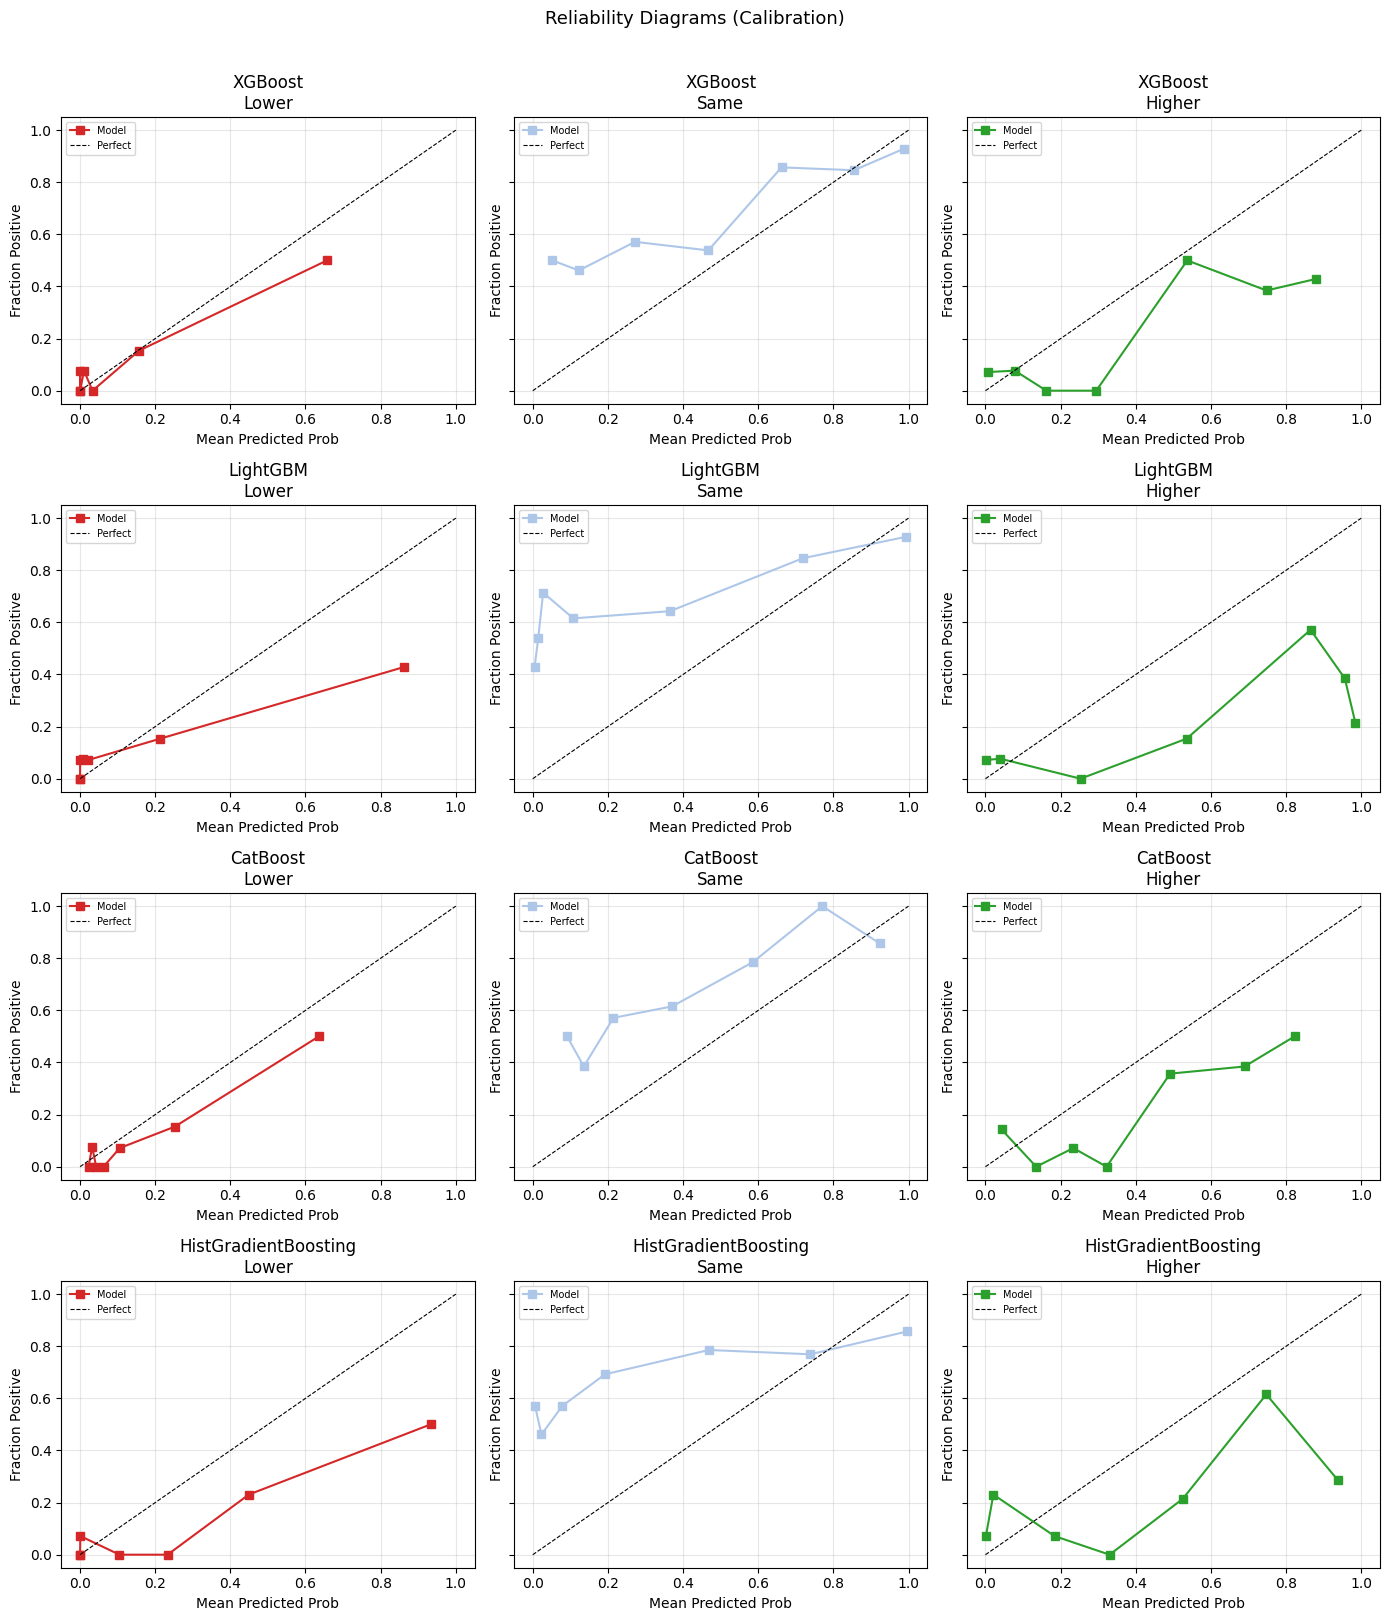

In [29]:
fig, axes = plt.subplots(len(final_results), 3,
                          figsize=(14, 4 * len(final_results)),
                          sharey=True)
if len(final_results) == 1:
    axes = [axes]

class_colors = ['#d62728', '#aec7e8', '#2ca02c']

for row_axes, (model_key, r) in zip(axes, final_results.items()):
    probs    = r['probas']
    act_enc  = r['actuals_enc']
    y_onehot = label_binarize(act_enc, classes=[0, 1, 2])

    for k, (ax, cls_name, color) in enumerate(zip(row_axes, LABEL_STRS, class_colors)):
        try:
            frac_pos, mean_pred = calibration_curve(
                y_onehot[:, k], probs[:, k], n_bins=7, strategy='quantile'
            )
            ax.plot(mean_pred, frac_pos, 's-', color=color, label='Model', linewidth=1.5)
        except ValueError:
            pass

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect')
        ax.set_title(f'{r["name"]}\n{cls_name}')
        ax.set_xlabel('Mean Predicted Prob')
        ax.set_ylabel('Fraction Positive')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig.suptitle('Reliability Diagrams (Calibration)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Regime-Learning Diagnostics

These four charts ask a different question from Section 7b.  
**Section 7b** asks: *Was the model right?*  
**Section 8** asks: *Did the model learn macro-policy structure?*

| Cell | Chart | What it reveals |
|------|-------|-----------------|
| 8-data | `df_regime` builder | Shared data structure for all charts below |
| 8a | **Macro Backdrop + Probability Overlay** | Do model probabilities shift in sync with CPI, UNRATE, WTI turning points? |
| 8b | **Macro Regime Heatmap** | Does the model output a stable hike/cut surface across CPI × UNRATE space? |
| 8c | **Phase-Space Scatter** | Do hike/cut probability scores cluster in the correct macro quadrants? |
| 8d | **Policy Surface + Feature Importance** | Which features drive the model; does the policy surface look Taylor-Rule-like? |

> **SHAP note:** `shap` cannot run in this environment (NumPy 2.x binary incompatibility).  
> Section 8d instead uses sklearn `permutation_importance` and a manual 2-D partial-dependence sweep — which reveals the same nonlinear regime logic without requiring SHAP.

In [30]:
# ── 8-data. Regime Data Builder ───────────────────────────────────────────────
# Build df_regime: one row per test-set FOMC meeting.
# Columns:
#   date          – FOMC meeting date
#   CPI_YoY       – concurrent CPI year-over-year % (raw, not lagged)
#   UNRATE        – concurrent unemployment rate %
#   DCOILWTICO    – concurrent WTI spot price ($/bbl)
#   WTI_mom6      – 6-meeting WTI % change (momentum proxy)
#   {pfx}_pL/pS/pH – P(Lower/Same/Higher) for each model
#   {pfx}_rs       – regime_score = P(Higher) - P(Lower)
#   actual_enc    – encoded true decision (0=Lower, 1=Same, 2=Higher)
#   actual_label  – string label

_test_dates_dt = pd.to_datetime(meeting_dates[INITIAL_TRAIN_SIZE:])

# ── Guard: reload macro series if not already in kernel scope ─────────────────
# URLs are resolved lazily so this cell works even if Section 1 was not run.
import pandas as _pd_guard

_BASE_URL = 'https://raw.githubusercontent.com/echochoho1010/forecasting_fed_rate/master/data'
_MACRO_SPECS = {
    'df_unrate': (
        globals().get('URL_UNRATE', f'{_BASE_URL}/Unemployment%20Rate%20UNRATE%20all.csv'),
        'UNRATE',
    ),
    'df_wti': (
        globals().get('URL_WTI', f'{_BASE_URL}/WTI%20Crude%20Oil%20Prices%20all.csv'),
        'DCOILWTICO',
    ),
    'df_cpi': (
        globals().get('URL_CPI', f'{_BASE_URL}/CPI%20All%20Urban%20Consumers%20all.csv'),
        'CPIAUCSL',
    ),
}

for _vname, (_url, _num_col) in _MACRO_SPECS.items():
    if _vname not in globals():
        _df = _pd_guard.read_csv(_url)
        _df['observation_date'] = _pd_guard.to_datetime(_df['observation_date'])
        _df[_num_col] = _pd_guard.to_numeric(_df[_num_col], errors='coerce')
        _df = _df.dropna().sort_values('observation_date').reset_index(drop=True)
        if _vname == 'df_cpi':
            _df['CPI_YoY'] = _df['CPIAUCSL'].pct_change(12) * 100
            _df = _df.dropna(subset=['CPI_YoY']).reset_index(drop=True)
        globals()[_vname] = _df
        print(f'  ↳ Reloaded {_vname} ({len(_df)} rows)')
# ─────────────────────────────────────────────────────────────────────────────

# ── Merge concurrent raw macro values at each meeting date ────────────────────
_td = pd.DataFrame({'date': _test_dates_dt}).sort_values('date')

def _safe_merge(base, src, date_col, val_cols):
    """merge_asof with backward fill; silently skips if src is undefined."""
    try:
        _s = src[[date_col] + val_cols].rename(columns={date_col: 'date'}).sort_values('date')
        return pd.merge_asof(base, _s, on='date', direction='backward')
    except Exception:
        return base

_td = _safe_merge(_td, df_cpi,    'observation_date', ['CPI_YoY'])
_td = _safe_merge(_td, df_unrate, 'observation_date', ['UNRATE'])
_td = _safe_merge(_td, df_wti,    'observation_date', ['DCOILWTICO'])

# ── Register available models (mirrors sync_check_001) ────────────────────────
_AVAIL = {}   # model_name → (short_prefix, proba_array)
if XGBOOST_AVAILABLE    and 'XGBoost'             in final_results:
    _AVAIL['XGBoost']       = ('xgb', final_results['XGBoost']['probas'])
if LGBM_AVAILABLE       and 'LightGBM'            in final_results:
    _AVAIL['LightGBM']      = ('lgb', final_results['LightGBM']['probas'])
if CATBOOST_AVAILABLE   and 'CatBoost'            in final_results:
    _AVAIL['CatBoost']      = ('cat', final_results['CatBoost']['probas'])
if 'HistGradientBoosting' in final_results:
    _AVAIL['HistGradBoost'] = ('hgb', final_results['HistGradientBoosting']['probas'])

_MODEL_CLRS = {
    'XGBoost':       '#1f77b4',
    'LightGBM':      '#ff7f0e',
    'CatBoost':      '#2ca02c',
    'HistGradBoost': '#d62728',
}

for _mname, (_pfx, _probs) in _AVAIL.items():
    _n = min(len(_probs), len(_td))
    _td.loc[_td.index[:_n], f'{_pfx}_pL'] = _probs[:_n, 0]
    _td.loc[_td.index[:_n], f'{_pfx}_pS'] = _probs[:_n, 1]
    _td.loc[_td.index[:_n], f'{_pfx}_pH'] = _probs[:_n, 2]
    _td.loc[_td.index[:_n], f'{_pfx}_rs'] = _probs[:_n, 2] - _probs[:_n, 0]

# ── Actual decisions ──────────────────────────────────────────────────────────
_acts_enc = final_results[
    'XGBoost' if 'XGBoost' in final_results else
    'HistGradientBoosting' if 'HistGradientBoosting' in final_results else
    list(final_results.keys())[0]
]['actuals_enc']
_n_act = min(len(_acts_enc), len(_td))
_td.loc[_td.index[:_n_act], 'actual_enc']   = _acts_enc[:_n_act].astype(float)
_td.loc[_td.index[:_n_act], 'actual_label'] = [ENCODED_NAMES[int(e)]
                                                for e in _acts_enc[:_n_act]]

# ── WTI 6-meeting momentum ────────────────────────────────────────────────────
_td['WTI_mom6'] = _td['DCOILWTICO'].pct_change(6).fillna(0)

df_regime = _td.reset_index(drop=True)

# ── Primary model for single-model charts ────────────────────────────────────
_PRIMARY = 'XGBoost' if 'XGBoost' in _AVAIL else list(_AVAIL.keys())[0]
_PPFX    = _AVAIL[_PRIMARY][0]

print(f'df_regime : {len(df_regime)} test meetings  '
      f'({df_regime["date"].min().date()} → {df_regime["date"].max().date()})')
print(f'Macro cols available: '
      f'CPI_YoY={df_regime["CPI_YoY"].notna().sum()} | '
      f'UNRATE={df_regime["UNRATE"].notna().sum()} | '
      f'WTI={df_regime["DCOILWTICO"].notna().sum()}')
print(f'Models registered : {list(_AVAIL.keys())}')
print(f'Primary (single-model charts): {_PRIMARY}')


  ↳ Reloaded df_unrate (481 rows)
  ↳ Reloaded df_wti (10109 rows)
  ↳ Reloaded df_cpi (468 rows)
df_regime : 95 test meetings  (2014-09-17 → 2026-01-28)
Macro cols available: CPI_YoY=95 | UNRATE=95 | WTI=95
Models registered : ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradBoost']
Primary (single-model charts): XGBoost


### 8a. Macro Backdrop + Model Probability Overlay

**What to look for:**
- When **CPI YoY spikes** (2021-22 inflation surge), does **P(Higher)** spike in sync?
- When **UNRATE surges** (COVID 2020), does **P(Lower)** spike?
- Do probability transitions precede or lag macro turning points?
- The coloured shading marks known Fed policy regimes — probabilities should be consistently high/low within each band.

Each model is one line; good regime capture = all four lines moving together and in macro-consistent direction.

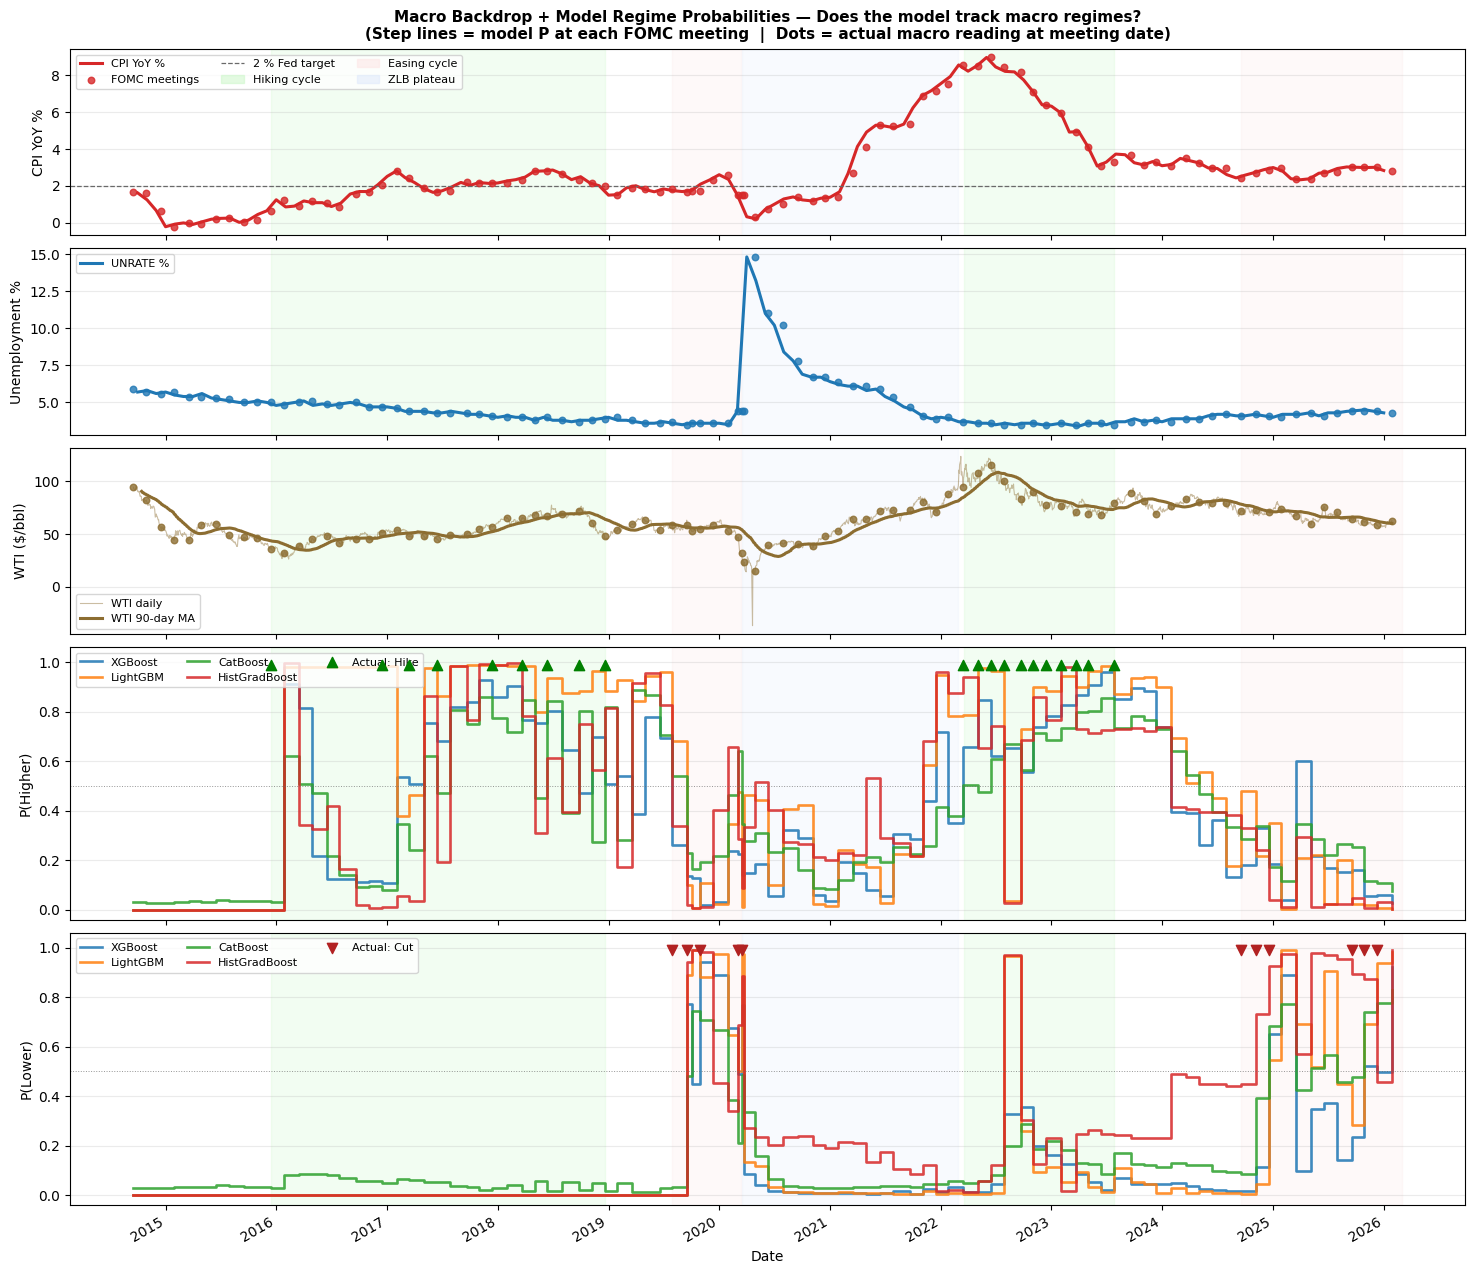

In [31]:

# ── 8a. Macro Backdrop + Model Probability Overlay ───────────────────────────
# 5 panels with shared x-axis covering the full test window.
# Panels 0-2: continuous raw macro series (from df_cpi / df_unrate / df_wti).
# Panels 3-4: P(Higher) and P(Lower) as step functions at FOMC meeting dates.
# Background shading: known Fed policy regime periods.

def plot_macro_backdrop(df_r, avail, model_clrs):
    # ── Regime shading bands (hardcoded from FOMC history) ───────────────────
    _SHADES = [
        ('2015-12-16', '2018-12-19', 'Hiking cycle',   '#c8f7c5', 0.22),
        ('2019-07-31', '2020-03-14', 'Easing cycle',   '#fce4e4', 0.22),
        ('2020-03-15', '2022-02-28', 'ZLB plateau',    '#dde8fb', 0.20),
        ('2022-03-17', '2023-07-26', 'Hiking cycle',   '#c8f7c5', 0.22),
        ('2024-09-18', '2026-03-01', 'Easing cycle',   '#fce4e4', 0.22),
    ]

    _t0 = df_r['date'].min()
    _t1 = df_r['date'].max()

    # ── Pull continuous macro series filtered to test window ─────────────────
    try:
        _cpi_c  = df_cpi[(df_cpi['observation_date'] >= _t0) &
                          (df_cpi['observation_date'] <= _t1)]
        _un_c   = df_unrate[(df_unrate['observation_date'] >= _t0) &
                             (df_unrate['observation_date'] <= _t1)]
        _wti_c  = df_wti[(df_wti['observation_date'] >= _t0) &
                          (df_wti['observation_date'] <= _t1)].copy()
        _wti_c['WTI_ma90'] = _wti_c['DCOILWTICO'].rolling(90, min_periods=20).mean()
        _has_cont = True
    except Exception:
        _has_cont = False

    fig, axes = plt.subplots(
        5, 1, figsize=(18, 17), sharex=True,
        gridspec_kw={'height_ratios': [1.3, 1.3, 1.3, 1.9, 1.9], 'hspace': 0.06}
    )

    # Apply regime shading to every panel
    import matplotlib.patches as mpatches
    _shade_handles = {}
    for ax in axes:
        for _rs, _re, _rlbl, _rcol, _ralpha in _SHADES:
            _p = ax.axvspan(pd.Timestamp(_rs), pd.Timestamp(_re),
                            alpha=_ralpha, color=_rcol, zorder=0)
            if _rlbl not in _shade_handles:
                _shade_handles[_rlbl] = mpatches.Patch(color=_rcol, alpha=0.5, label=_rlbl)

    # ── Panel 0: CPI YoY (%) ─────────────────────────────────────────────────
    ax = axes[0]
    if _has_cont:
        ax.plot(_cpi_c['observation_date'], _cpi_c['CPI_YoY'],
                color='#d62728', lw=2.2, label='CPI YoY %')
    ax.scatter(df_r['date'], df_r['CPI_YoY'], s=22, color='#d62728',
               zorder=5, alpha=0.8, label='FOMC meetings')
    ax.axhline(2.0, color='dimgray', lw=0.9, ls='--', label='2 % Fed target')
    ax.set_ylabel('CPI YoY %', fontsize=10)
    ax.grid(axis='y', alpha=0.25)
    _leg_macro = ax.get_legend_handles_labels()
    ax.legend(
        _leg_macro[0] + list(_shade_handles.values()),
        _leg_macro[1] + list(_shade_handles.keys()),
        loc='upper left', fontsize=8, ncol=3
    )
    ax.set_title(
        'Macro Backdrop + Model Regime Probabilities — Does the model track macro regimes?\n'
        '(Step lines = model P at each FOMC meeting  |  Dots = actual macro reading at meeting date)',
        fontsize=11, fontweight='bold', pad=7
    )

    # ── Panel 1: Unemployment Rate (%) ────────────────────────────────────────
    ax = axes[1]
    if _has_cont:
        ax.plot(_un_c['observation_date'], _un_c['UNRATE'],
                color='#1f77b4', lw=2.2, label='UNRATE %')
    ax.scatter(df_r['date'], df_r['UNRATE'], s=22, color='#1f77b4',
               zorder=5, alpha=0.8)
    ax.set_ylabel('Unemployment %', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

    # ── Panel 2: WTI Crude Oil ($/bbl) ───────────────────────────────────────
    ax = axes[2]
    if _has_cont:
        ax.plot(_wti_c['observation_date'], _wti_c['DCOILWTICO'],
                color='#8c6d31', lw=0.8, alpha=0.45, label='WTI daily')
        ax.plot(_wti_c['observation_date'], _wti_c['WTI_ma90'],
                color='#8c6d31', lw=2.2, label='WTI 90-day MA')
    ax.scatter(df_r['date'], df_r['DCOILWTICO'], s=22, color='#8c6d31',
               zorder=5, alpha=0.8)
    ax.set_ylabel('WTI ($/bbl)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

    # ── Panel 3: P(Higher) — all models as step function ─────────────────────
    ax = axes[3]
    for _mname, (_pfx, _) in avail.items():
        _col  = model_clrs.get(_mname, 'black')
        _vals = df_r[f'{_pfx}_pH'].dropna()
        _dts  = df_r.loc[_vals.index, 'date']
        ax.step(_dts, _vals, color=_col, lw=1.9, alpha=0.85,
                where='post', label=_mname)
    # Actual hike markers
    _hike = df_r['actual_enc'] == 2
    ax.scatter(df_r.loc[_hike, 'date'], np.full(_hike.sum(), 0.99),
               marker='^', color='green', s=55, zorder=9,
               clip_on=False, label='Actual: Hike')
    ax.axhline(0.5, color='dimgray', lw=0.7, ls=':', alpha=0.7)
    ax.set_ylim(-0.04, 1.06)
    ax.set_ylabel('P(Higher)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.grid(axis='y', alpha=0.25)

    # ── Panel 4: P(Lower) — all models as step function ──────────────────────
    ax = axes[4]
    for _mname, (_pfx, _) in avail.items():
        _col  = model_clrs.get(_mname, 'black')
        _vals = df_r[f'{_pfx}_pL'].dropna()
        _dts  = df_r.loc[_vals.index, 'date']
        ax.step(_dts, _vals, color=_col, lw=1.9, alpha=0.85,
                where='post', label=_mname)
    _cut = df_r['actual_enc'] == 0
    ax.scatter(df_r.loc[_cut, 'date'], np.full(_cut.sum(), 0.99),
               marker='v', color='firebrick', s=55, zorder=9,
               clip_on=False, label='Actual: Cut')
    ax.axhline(0.5, color='dimgray', lw=0.7, ls=':', alpha=0.7)
    ax.set_ylim(-0.04, 1.06)
    ax.set_ylabel('P(Lower)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8, ncol=3)
    ax.grid(axis='y', alpha=0.25)
    ax.set_xlabel('Date', fontsize=10)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


plot_macro_backdrop(df_regime, _AVAIL, _MODEL_CLRS)


### 8b. Macro Regime Heatmap

**What to look for:**
- A well-behaved model should show a clear gradient: **high CPI + low UNRATE → green (hike-leaning)** and **low CPI + high UNRATE → red (cut-leaning)**.  This is Taylor Rule logic — if the model learned it, the colour gradient should be diagonal.
- Flat or random colouring = the model is not using CPI × UNRATE interaction.
- One heatmap per model; diverging colour scale centred at 0 (neutral).  
- `regime_score = P(Higher) − P(Lower)`: positive = hike-leaning, negative = cut-leaning.

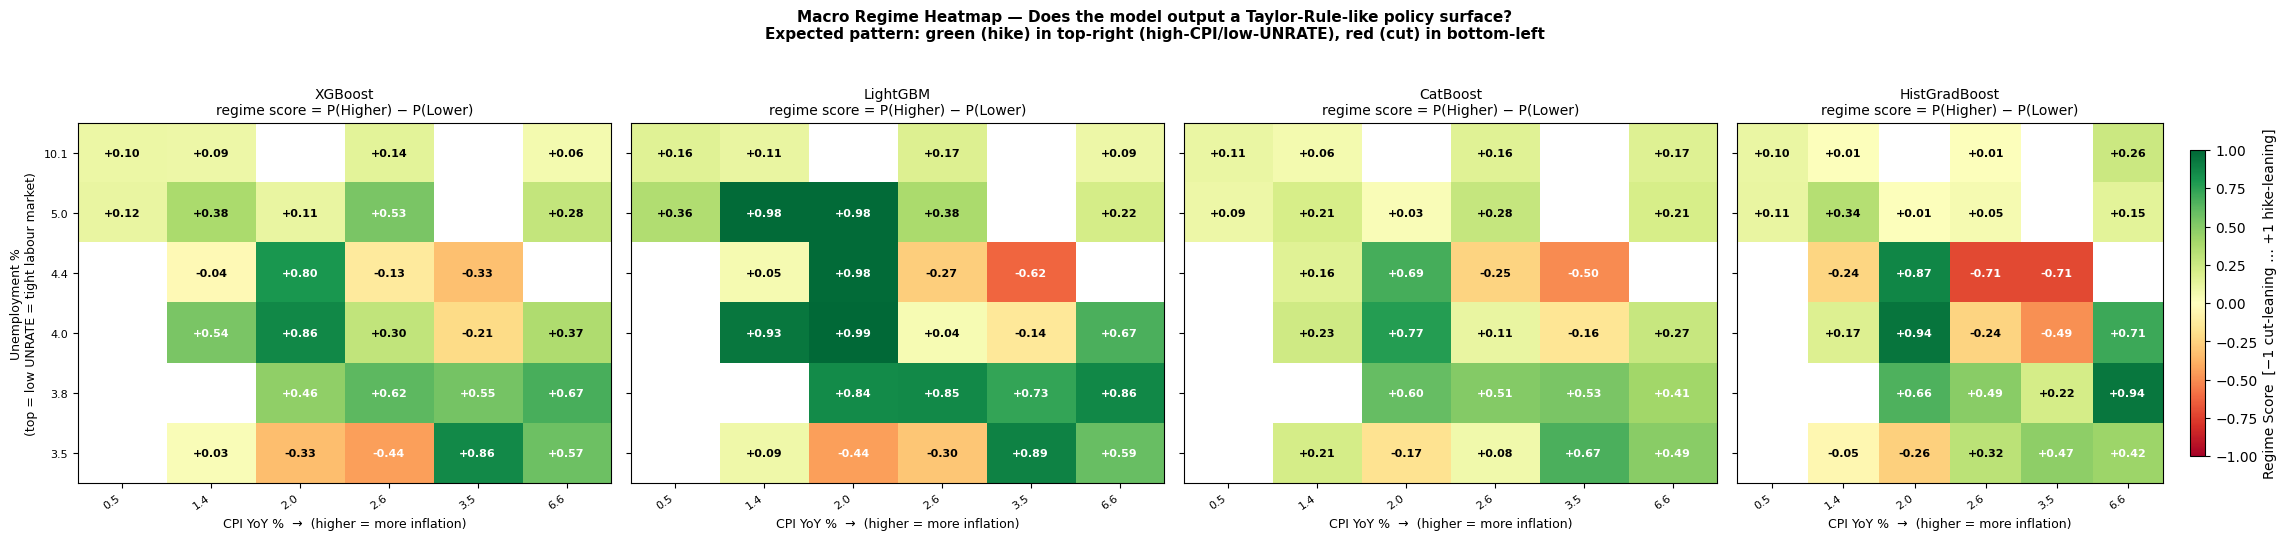

In [32]:

# ── 8b. Macro Regime Heatmap ─────────────────────────────────────────────────
# 2D heatmap: CPI YoY bins (x) × Unemployment bins (y) → mean regime_score.
# With only ~95 meetings, equal-frequency (qcut) bins avoid empty rows/columns.

def plot_regime_heatmap(df_r, avail, n_bins=6):
    """
    Parameters
    ----------
    df_r    : df_regime (one row per FOMC test meeting)
    avail   : _AVAIL dict  {model_name: (pfx, proba_array)}
    n_bins  : number of quantile bins for each axis (default 6)
    """
    _tmp = df_r[['CPI_YoY', 'UNRATE'] +
                [f'{pfx}_rs' for _, (pfx, _) in avail.items()]].dropna()

    if len(_tmp) < n_bins * 2:
        print('Too few non-NaN rows for heatmap — skipping.'); return

    # Equal-frequency bins so every cell has data
    _cpi_bins = pd.qcut(_tmp['CPI_YoY'], n_bins, duplicates='drop')
    _un_bins  = pd.qcut(_tmp['UNRATE'],  n_bins, duplicates='drop')

    _n_models = len(avail)
    fig, axes = plt.subplots(
        1, _n_models,
        figsize=(5.8 * _n_models, 5.2),
        sharey=True, squeeze=False
    )
    axes = axes[0]

    _last_im = None
    for ax, (_mname, (_pfx, _)) in zip(axes, avail.items()):
        _rs_col = f'{_pfx}_rs'

        # Pivot: rows = UNRATE bins (low→high), cols = CPI bins (low→high)
        _pivot = (
            _tmp.assign(_cb=_cpi_bins, _ub=_un_bins)
            .groupby(['_ub', '_cb'], observed=True)[_rs_col]
            .mean()
            .unstack('_cb')
        )

        # Build display matrix (flip so low UNRATE is at top = normal econ charts)
        _mat = _pivot.values[::-1]

        _im = ax.imshow(
            _mat, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1,
            interpolation='nearest'
        )
        _last_im = _im

        # Cell annotations
        for _i in range(_mat.shape[0]):
            for _j in range(_mat.shape[1]):
                _v = _mat[_i, _j]
                if not np.isnan(_v):
                    _tc = 'white' if abs(_v) > 0.38 else 'black'
                    ax.text(_j, _i, f'{_v:+.2f}',
                            ha='center', va='center', fontsize=8, color=_tc,
                            fontweight='bold')

        # Axis tick labels (midpoint of each bin)
        _cpi_mids = [f'{iv.mid:.1f}' for iv in _pivot.columns]
        _un_mids  = [f'{iv.mid:.1f}' for iv in _pivot.index[::-1]]
        ax.set_xticks(range(len(_cpi_mids)))
        ax.set_xticklabels(_cpi_mids, fontsize=8, rotation=35, ha='right')
        ax.set_yticks(range(len(_un_mids)))
        ax.set_yticklabels(_un_mids, fontsize=8)
        ax.set_xlabel('CPI YoY %  →  (higher = more inflation)', fontsize=9)
        if ax is axes[0]:
            ax.set_ylabel('Unemployment %\n(top = low UNRATE = tight labour market)',
                          fontsize=9)
        ax.set_title(f'{_mname}\nregime score = P(Higher) − P(Lower)', fontsize=10)

    if _last_im is not None:
        plt.colorbar(_last_im, ax=axes[-1], shrink=0.85,
                     label='Regime Score  [−1 cut-leaning … +1 hike-leaning]')

    fig.suptitle(
        'Macro Regime Heatmap — Does the model output a Taylor-Rule-like policy surface?\n'
        'Expected pattern: green (hike) in top-right (high-CPI/low-UNRATE), '
        'red (cut) in bottom-left',
        fontsize=11, fontweight='bold', y=1.03
    )
    plt.tight_layout()
    plt.show()


plot_regime_heatmap(df_regime, _AVAIL, n_bins=6)


### 8c. Regime Phase-Space Scatter

**What to look for:**
- Each point is one FOMC test meeting, placed at its **concurrent CPI × UNRATE coordinates**.
- **Color** = `regime_score = P(Higher) − P(Lower)`: green = model was hike-leaning, red = cut-leaning.
- **Marker shape** = actual Fed decision (▲ Hike, ● Hold, ▼ Cut).
- **Marker size** = magnitude of 6-meeting WTI momentum (larger = bigger oil swing).

**Good regime capture** looks like: green markers clustered in the high-CPI / low-UNRATE quadrant (top-right), red markers in the low-CPI / high-UNRATE quadrant (bottom-left). Shape and colour should agree — a ▲ should be green; a ▼ should be red.

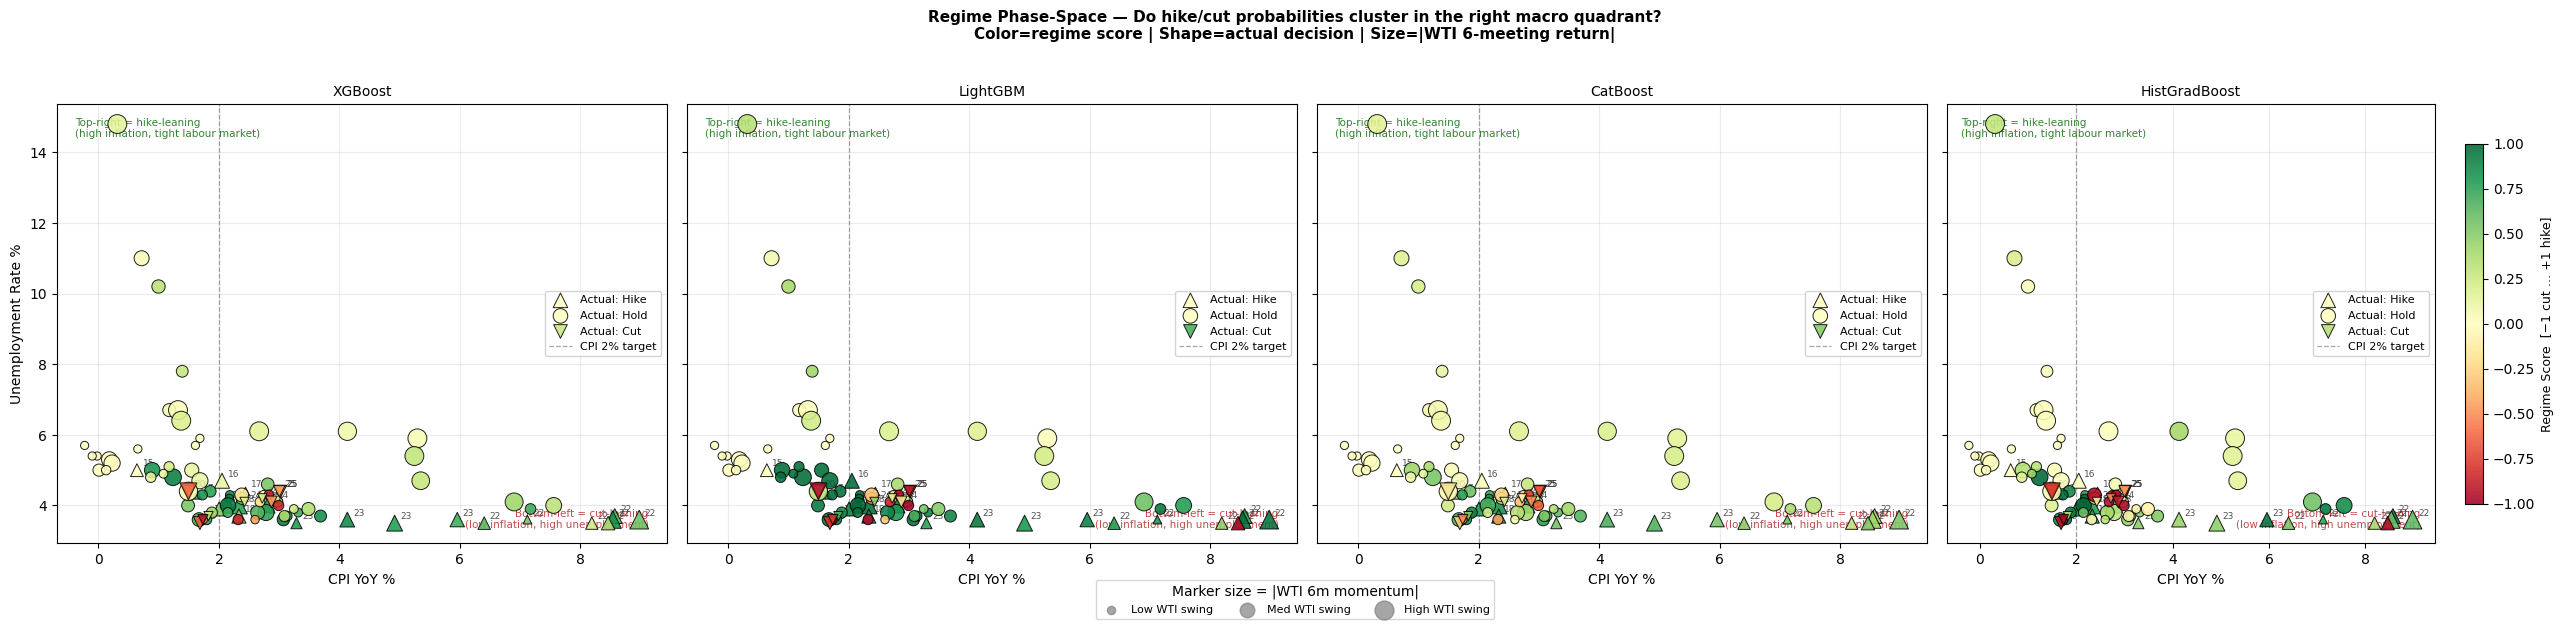

In [33]:

# ── 8c. Regime Phase-Space Scatter ───────────────────────────────────────────
# Each point = one FOMC test meeting.
#   x     = CPI YoY %
#   y     = Unemployment Rate %
#   color = regime_score (P(Higher) - P(Lower))   green=hike, red=cut
#   shape = actual FOMC decision                  ▲=hike, ●=hold, ▼=cut
#   size  = |WTI 6-meeting momentum|              bigger=larger oil swing

def plot_phase_space(df_r, avail, model_clrs):
    _DEC_CFG = {
        'Higher': ('^', 'Actual: Hike',  'black',  100),
        'Same':   ('o', 'Actual: Hold',  'black',   55),
        'Lower':  ('v', 'Actual: Cut',   'black',  100),
    }
    _cmap = plt.cm.RdYlGn

    _n_models = len(avail)
    fig, axes = plt.subplots(
        1, _n_models,
        figsize=(6.5 * _n_models, 5.8),
        sharey=True, squeeze=False
    )
    axes = axes[0]

    _last_sc = None
    for ax, (_mname, (_pfx, _)) in zip(axes, avail.items()):
        _rs_col = f'{_pfx}_rs'
        _tmp = df_r[['CPI_YoY', 'UNRATE', _rs_col,
                      'actual_label', 'WTI_mom6', 'date']].dropna(
            subset=['CPI_YoY', 'UNRATE', _rs_col]
        )

        # Marker size: WTI momentum magnitude, normalised to a readable range
        _wti_abs = _tmp['WTI_mom6'].abs().clip(0, 0.6)
        _sz_base = 35 + _wti_abs * 250   # range ≈ 35–185

        for _dec, (_mk, _lbl, _ec, _base_s) in _DEC_CFG.items():
            _mask = _tmp['actual_label'] == _dec
            if _mask.sum() == 0:
                continue
            _sc = ax.scatter(
                _tmp.loc[_mask, 'CPI_YoY'],
                _tmp.loc[_mask, 'UNRATE'],
                c=_tmp.loc[_mask, _rs_col],
                cmap=_cmap, vmin=-1, vmax=1,
                marker=_mk,
                s=_sz_base[_mask],
                edgecolors=_ec, linewidths=0.7,
                alpha=0.88, zorder=5, label=_lbl
            )
            _last_sc = _sc

        # Annotate hike/cut meetings with year labels
        for _dec in ('Higher', 'Lower'):
            _sub = _tmp[_tmp['actual_label'] == _dec]
            for _, _row in _sub.iterrows():
                ax.annotate(
                    _row['date'].strftime('%y'),
                    xy=(_row['CPI_YoY'], _row['UNRATE']),
                    fontsize=6.5, color='#333333', alpha=0.85,
                    xytext=(4, 3), textcoords='offset points'
                )

        # 2% CPI reference line
        ax.axvline(2.0, color='dimgray', lw=0.9, ls='--', alpha=0.6,
                   label='CPI 2% target')

        # Diagonal annotation (Taylor Rule intuition)
        ax.text(0.97, 0.03,
                'Bottom-left = cut-leaning\n(low inflation, high unemployment)',
                transform=ax.transAxes, fontsize=7.5, ha='right', va='bottom',
                color='firebrick', alpha=0.8)
        ax.text(0.03, 0.97,
                'Top-right = hike-leaning\n(high inflation, tight labour market)',
                transform=ax.transAxes, fontsize=7.5, ha='left', va='top',
                color='darkgreen', alpha=0.8)

        ax.set_xlabel('CPI YoY %', fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel('Unemployment Rate %', fontsize=10)
        ax.set_title(f'{_mname}', fontsize=10)
        ax.legend(loc='center right', fontsize=8, framealpha=0.85)
        ax.grid(alpha=0.25)

    if _last_sc is not None:
        _cb = plt.colorbar(_last_sc, ax=axes[-1], shrink=0.82)
        _cb.set_label('Regime Score  [−1 cut … +1 hike]', fontsize=9)

    # Size legend
    _sz_patches = [
        plt.scatter([], [], s=35,  marker='o', color='gray', alpha=0.7, label='Low WTI swing'),
        plt.scatter([], [], s=110, marker='o', color='gray', alpha=0.7, label='Med WTI swing'),
        plt.scatter([], [], s=185, marker='o', color='gray', alpha=0.7, label='High WTI swing'),
    ]
    fig.legend(handles=_sz_patches, title='Marker size = |WTI 6m momentum|',
               loc='lower center', fontsize=8, ncol=3, bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(
        'Regime Phase-Space — Do hike/cut probabilities cluster in the right macro quadrant?\n'
        'Color=regime score | Shape=actual decision | Size=|WTI 6-meeting return|',
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()


plot_phase_space(df_regime, _AVAIL, _MODEL_CLRS)
